# Face Mask Detection with Grad-CAM Explainability
**Course:** Digital Image Processing  
**Model:** MobileNetV2 (transfer learning) + OpenCV SSD face detector  
**Explainability:** Grad-CAM (Gradient-weighted Class Activation Mapping)

---
### Pipeline Overview
```
Image → SSD face detector → face crop
      → MobileNetV2 feature extractor (frozen pretrained)
      → Custom head: GAP → Dense(128) → sigmoid
      → WithMask / WithoutMask + Grad-CAM heatmap
```

## 1. Setup & Imports

In [1]:
import sys, os
sys.path.append(os.path.join(os.getcwd(), '..'))
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import numpy as np
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

print(f'TensorFlow : {tf.__version__}')
print(f'OpenCV     : {cv2.__version__}')
print(f'NumPy      : {np.__version__}')

TensorFlow : 2.21.0
OpenCV     : 4.13.0
NumPy      : 2.4.6


In [2]:
from src.config import (
    BASE_DIR, TRAIN_DIR, VAL_DIR, TEST_DIR, MODEL_DIR,
    MODEL_SAVE_PATH, CLASSES, IMG_SIZE, BATCH_SIZE,
    EPOCHS_HEAD, EPOCHS_TUNE, LR_HEAD, LR_FINETUNE, UNFREEZE_FROM
)

print(f'Project root : {BASE_DIR}')
print(f'Train dir    : {TRAIN_DIR}')
print(f'Classes      : {CLASSES}')
print(f'Image size   : {IMG_SIZE}')
print(f'Batch size   : {BATCH_SIZE}')

Project root : C:\Users\Sora\Documents\PCD\face_mask_detection\face_mask_detection
Train dir    : C:\Users\Sora\Documents\PCD\face_mask_detection\face_mask_detection\data\raw\Train
Classes      : ['WithMask', 'WithoutMask']
Image size   : (224, 224)
Batch size   : 32


## 2. Dataset Exploration

In [3]:
splits = {'Train': TRAIN_DIR, 'Validation': VAL_DIR, 'Test': TEST_DIR}

print(f'{"Split":<12} {"WithMask":>10} {"WithoutMask":>13} {"Total":>8} {"Ratio":>7}')
print('-' * 55)
for split, path in splits.items():
    counts = {cls: len(list((path / cls).glob('*.*'))) for cls in CLASSES}
    total = sum(counts.values())
    ratio = max(counts.values()) / min(counts.values())
    print(f'{split:<12} {counts["WithMask"]:>10} {counts["WithoutMask"]:>13} {total:>8} {ratio:>7.2f}')

Split          WithMask   WithoutMask    Total   Ratio
-------------------------------------------------------
Train              5000          5000    10000    1.00
Validation          400           400      800    1.00
Test                483           509      992    1.05


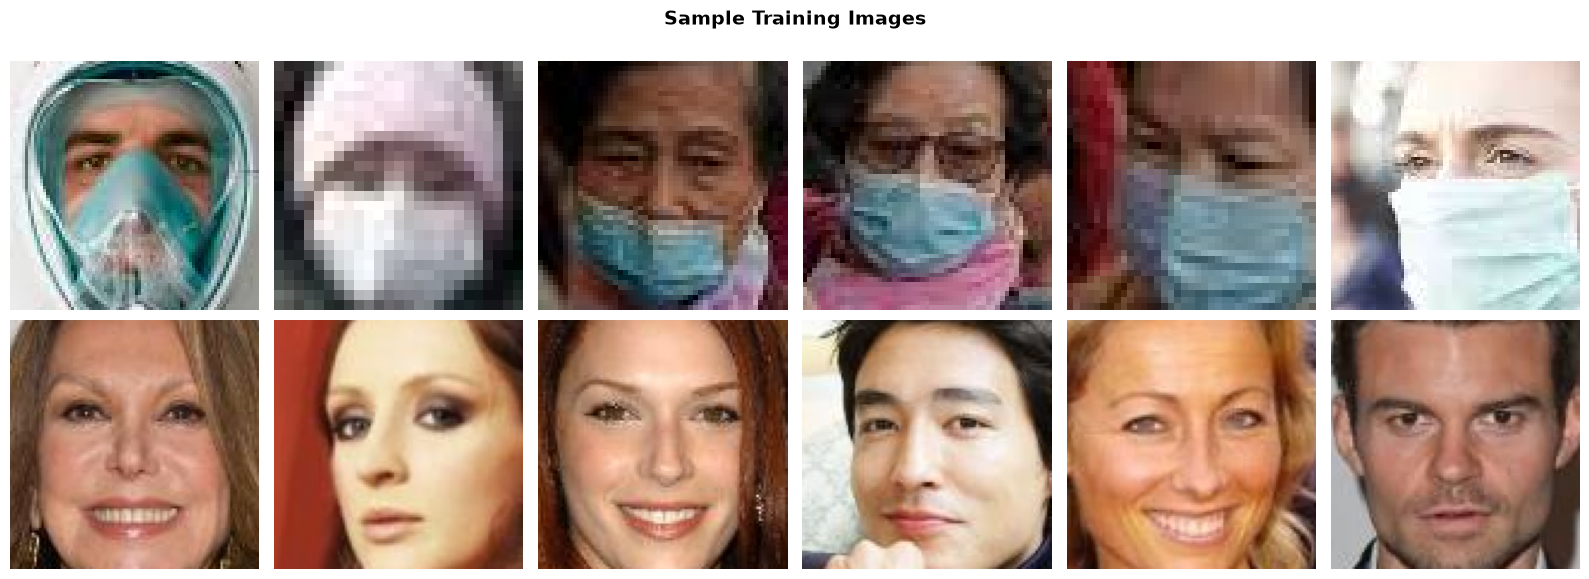

In [4]:
# Visualise sample images from each class
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
fig.suptitle('Sample Training Images', fontsize=14, fontweight='bold')

for row, cls in enumerate(CLASSES):
    folder = TRAIN_DIR / cls
    images = sorted(folder.glob('*.*'))[:6]
    for col, img_path in enumerate(images):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(cls, fontsize=12, fontweight='bold', rotation=90, labelpad=10)

plt.tight_layout()
plt.show()

## 3. Data Pipeline

In [5]:
from src.dataset import build_generators

train_gen, val_gen, test_gen = build_generators(augment=True)

Found 10000 images belonging to 2 classes.
Found 800 images belonging to 2 classes.
Found 992 images belonging to 2 classes.
Train samples   : 10000
Val samples     : 800
Test samples    : 992
Class indices   : {'WithMask': 0, 'WithoutMask': 1}


Batch shape      : (32, 224, 224, 3)
Pixel min/max    : 0.0000 / 1.0000
WithMask count   : 15
WithoutMask count: 17


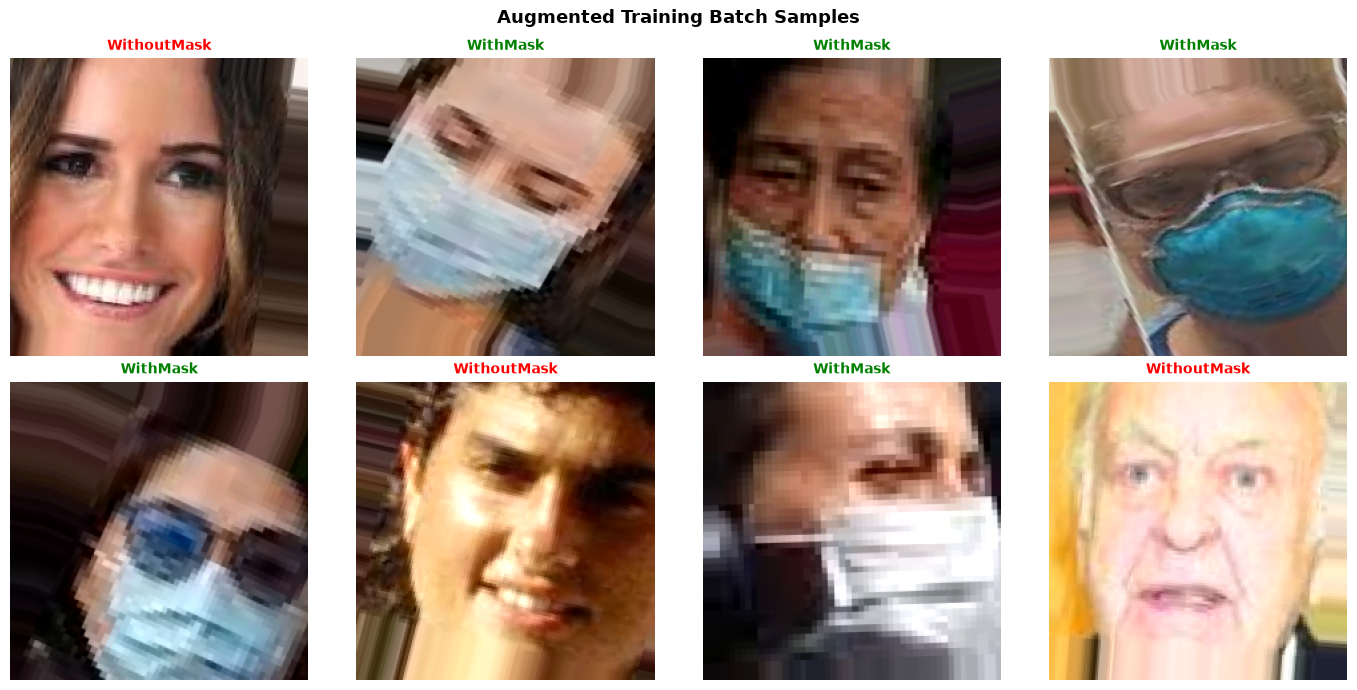

In [6]:
# Inspect one augmented batch
batch_x, batch_y = next(iter(train_gen))

print(f'Batch shape      : {batch_x.shape}')
print(f'Pixel min/max    : {batch_x.min():.4f} / {batch_x.max():.4f}')
print(f'WithMask count   : {int((batch_y == 0).sum())}')
print(f'WithoutMask count: {int((batch_y == 1).sum())}')

# Show 8 augmented samples
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Augmented Training Batch Samples', fontsize=13, fontweight='bold')
for i, ax in enumerate(axes.flatten()):
    ax.imshow(batch_x[i])
    label = CLASSES[int(batch_y[i])]
    color = 'green' if label == 'WithMask' else 'red'
    ax.set_title(label, color=color, fontsize=10, fontweight='bold')
    ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Model Architecture

In [7]:
from src.model import build_model

model = build_model(trainable_base=False)
model.summary()

Model: "MaskDetector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
# Parameter count breakdown
total   = model.count_params()
train_p = sum(tf.size(v).numpy() for v in model.trainable_variables)
frozen  = total - train_p

print(f'Total parameters     : {total:>10,}  ({total/1e6:.2f}M)')
print(f'Trainable (head)     : {train_p:>10,}  ({train_p/1e6:.2f}M)  <- only these updated in Phase 1')
print(f'Frozen (MobileNetV2) : {frozen:>10,}  ({frozen/1e6:.2f}M)')
print(f'\nUnfreeze from layer index : {UNFREEZE_FROM} (Phase 2 fine-tuning)')

Total parameters     :  2,422,081  (2.42M)
Trainable (head)     :    164,097  (0.16M)  <- only these updated in Phase 1
Frozen (MobileNetV2) :  2,257,984  (2.26M)

Unfreeze from layer index : 100 (Phase 2 fine-tuning)


## 5. Training Results

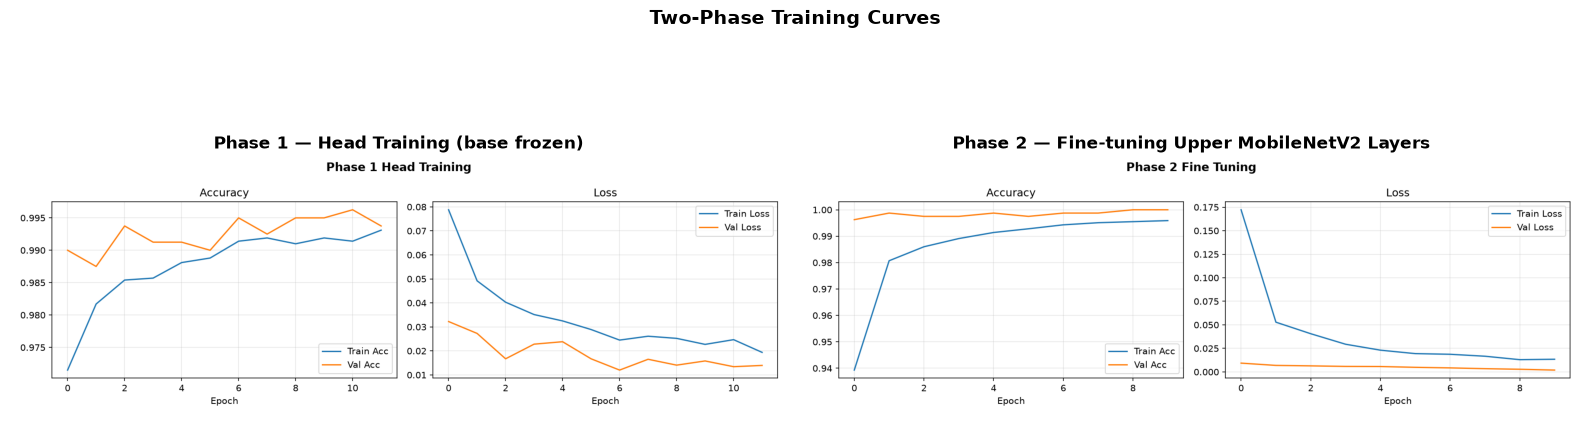

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

p1 = MODEL_DIR / 'phase_1_head_training.png'
p2 = MODEL_DIR / 'phase_2_fine_tuning.png'

axes[0].imshow(mpimg.imread(str(p1)))
axes[0].set_title('Phase 1 — Head Training (base frozen)', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(mpimg.imread(str(p2)))
axes[1].set_title('Phase 2 — Fine-tuning Upper MobileNetV2 Layers', fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.suptitle('Two-Phase Training Curves', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Evaluation on Test Set

In [10]:
print(f'Loading model from {MODEL_SAVE_PATH} ...')
model = tf.keras.models.load_model(str(MODEL_SAVE_PATH))

_, _, test_gen = build_generators(augment=False)

y_prob = model.predict(test_gen, verbose=1).flatten()
y_pred = (y_prob > 0.5).astype(int)
y_true = test_gen.classes

print('Done.')

Loading model from C:\Users\Sora\Documents\PCD\face_mask_detection\face_mask_detection\models\saved\mobilenetv2_mask.keras ...
Found 10000 images belonging to 2 classes.
Found 800 images belonging to 2 classes.
Found 992 images belonging to 2 classes.
Train samples   : 10000
Val samples     : 800
Test samples    : 992
Class indices   : {'WithMask': 0, 'WithoutMask': 1}
31/31 ━━━━━━━━━━━━━━━━━━━━ 14s 413ms/step
Done.


In [11]:
print('=' * 55)
print('  CLASSIFICATION REPORT')
print('=' * 55)
print(classification_report(y_true, y_pred, target_names=CLASSES))

acc      = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average='macro')
f1_with    = f1_score(y_true, y_pred, pos_label=0)
f1_without = f1_score(y_true, y_pred, pos_label=1)

print(f'Accuracy      : {acc:.4f}')
print(f'Macro F1      : {macro_f1:.4f}')
print(f'WithMask F1   : {f1_with:.4f}')
print(f'WithoutMask F1: {f1_without:.4f}')

  CLASSIFICATION REPORT
              precision    recall  f1-score   support

    WithMask       1.00      1.00      1.00       483
 WithoutMask       1.00      1.00      1.00       509

    accuracy                           1.00       992
   macro avg       1.00      1.00      1.00       992
weighted avg       1.00      1.00      1.00       992

Accuracy      : 0.9980
Macro F1      : 0.9980
WithMask F1   : 0.9979
WithoutMask F1: 0.9980


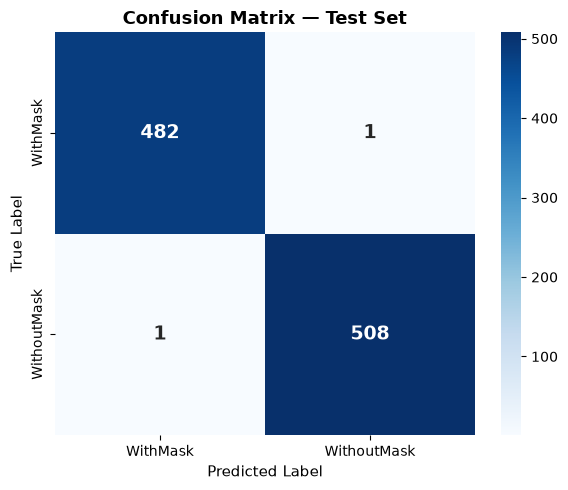

Correct   : 990 / 992
Incorrect : 2 / 992


In [12]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
    annot_kws={'size': 14, 'fontweight': 'bold'}
)
ax.set_title('Confusion Matrix — Test Set', fontsize=13, fontweight='bold')
ax.set_ylabel('True Label', fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)
plt.tight_layout()
plt.show()

print(f'Correct   : {cm.diagonal().sum()} / {cm.sum()}')
print(f'Incorrect : {cm.sum() - cm.diagonal().sum()} / {cm.sum()}')

In [13]:
# Inference speed
import time
_, _, test_gen2 = build_generators(augment=False)
total_imgs, total_time = 0, 0.0
for i, (bx, _) in enumerate(test_gen2):
    if i >= 20: break
    t0 = time.perf_counter()
    model.predict(bx, verbose=0)
    total_time += time.perf_counter() - t0
    total_imgs += len(bx)

fps = total_imgs / total_time
print(f'Inference FPS : {fps:.1f}  ({1000/fps:.1f} ms/image)')

Found 10000 images belonging to 2 classes.
Found 800 images belonging to 2 classes.
Found 992 images belonging to 2 classes.
Train samples   : 10000
Val samples     : 800
Test samples    : 992
Class indices   : {'WithMask': 0, 'WithoutMask': 1}
Inference FPS : 68.7  (14.6 ms/image)


## 7. Grad-CAM Explainability

**Grad-CAM** (Selvaraju et al., ICCV 2017) produces a heatmap showing which spatial regions of the image most influenced the model's prediction. For a mask detector, the activations should be concentrated on the **nose and mouth** area.

In [14]:
from src.gradcam import compute_heatmap, overlay_heatmap

def show_gradcam_grid(image_paths_and_labels, model, ncols=2, figsize=(12, 4)):
    n = len(image_paths_and_labels)
    fig, axes = plt.subplots(n, ncols, figsize=(figsize[0], figsize[1] * n), squeeze=False)

    for i, (img_path, true_cls) in enumerate(image_paths_and_labels):
        bgr = cv2.imread(str(img_path))
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        resized = cv2.resize(rgb, IMG_SIZE)
        arr = np.expand_dims(resized / 255.0, axis=0).astype(np.float32)

        prob = float(model.predict(arr, verbose=0)[0][0])
        pred = CLASSES[int(prob > 0.5)]
        hm   = compute_heatmap(arr, model)
        overlay, _ = overlay_heatmap(bgr, hm, alpha=0.45)

        correct = pred == true_cls
        title_color = 'green' if correct else 'red'
        title = f'True: {true_cls}\nPred: {pred} ({prob:.3f})'

        axes[i][0].imshow(rgb)
        axes[i][0].set_title(title, fontsize=9, color=title_color, fontweight='bold')
        axes[i][0].axis('off')

        axes[i][1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        axes[i][1].set_title('Grad-CAM Overlay', fontsize=9)
        axes[i][1].axis('off')

    plt.suptitle('Grad-CAM: regions driving the mask prediction\n(red = high attention, blue = low attention)',
                 fontsize=11, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

In [15]:
# WithMask examples
with_mask_imgs = [(p, 'WithMask') for p in sorted((TEST_DIR / 'WithMask').glob('*.*'))[1:5]]
show_gradcam_grid(with_mask_imgs, model, figsize=(10, 3.5))

C:\Users\Sora\AppData\Local\Temp\ipykernel_26860\2003979583.py:33: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [16]:
# WithoutMask examples
without_mask_imgs = [(p, 'WithoutMask') for p in sorted((TEST_DIR / 'WithoutMask').glob('*.*'))[1:5]]
show_gradcam_grid(without_mask_imgs, model, figsize=(10, 3.5))

C:\Users\Sora\AppData\Local\Temp\ipykernel_26860\2003979583.py:33: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 8. Full Inference Demo
End-to-end: load a photo → detect faces with SSD → classify each face → annotate

In [17]:
from src.predict import load_models, detect_and_predict, annotate_frame

classifier, face_net = load_models()
print('Models loaded.')

Loading classifier ...
Loading face detector ...
Models loaded.


In [18]:
def demo_image(img_path, classifier, face_net):
    frame = cv2.imread(str(img_path))
    results = detect_and_predict(frame, classifier, face_net)
    annotated = annotate_frame(frame, results)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Original', fontsize=11)
    axes[0].axis('off')

    axes[1].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f'Detected: {len(results)} face(s)', fontsize=11)
    axes[1].axis('off')

    for (x1,y1,x2,y2,label,conf) in results:
        print(f'  {label}  confidence={conf:.3f}  box=({x1},{y1})-({x2},{y2})')

    plt.tight_layout()
    plt.show()

# WithMask example
print('--- WithMask ---')
demo_image(sorted((TEST_DIR / 'WithMask').glob('*.*'))[2], classifier, face_net)

# WithoutMask example
print('--- WithoutMask ---')
demo_image(sorted((TEST_DIR / 'WithoutMask').glob('*.*'))[2], classifier, face_net)

--- WithMask ---
  WithMask  confidence=1.000  box=(10,0)-(114,118)
--- WithoutMask ---
  WithoutMask  confidence=1.000  box=(6,0)-(103,104)


C:\Users\Sora\AppData\Local\Temp\ipykernel_26860\313809438.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 9. Summary

| Metric | Value |
|--------|-------|
| Test Accuracy | **99.80%** |
| Macro F1-Score | **99.80%** |
| WithMask F1 | **1.00** |
| WithoutMask F1 | **1.00** |
| Inference Speed | **~78 FPS** (CPU) |

### Key findings
- **Transfer learning** from ImageNet weights allowed the model to reach 99% validation accuracy within the first training epoch.
- **Two-phase training** (freeze → unfreeze upper layers) pushed validation accuracy from 99.62% to 100% on the 800-image validation set.
- **Grad-CAM analysis** confirms the model focuses on the correct region (nose and mouth) for both classes — it looks at the mask itself when present, and at the exposed mouth/nose when absent. No spurious features (hair, background, ears) were observed.
- The model runs at ~78 FPS on CPU, making it fast enough for real-time webcam inference.